# **Los 4 Ejercicios del notebook de Astroquery** 
Estudiante: Juan Diego Rodríguez \
Profesor: José Iván Campos Rozo \
**Observatorio Astronómico Nacional, Semestre 2026-1**

## **Primer Ejercicio:** Identifique al menos tres de las líneas observadas en el espectro de NGC 5406. Utilizando esa información, ¿cuál es el corrimiento al rojo (redshift) de esta galaxia?
 

In [11]:
import matplotlib 
#matplotlib.use('Agg')

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline 

# Python standard-libraries to download data from the web
from urllib.parse import urlencode
from urllib.request import urlretrieve

#Some astropy submodules that you know already
from astropy import units as u
from astropy import coordinates as coords
from astropy.coordinates import SkyCoord
from astropy.io import fits

#only here to display images
from IPython.display import Image

# These are the new modules for this notebook
from astroquery.simbad import Simbad
from astroquery.sdss import SDSS

In [30]:
galaxy_name = 'NGC5406'

# Information from the name of the galaxy in the SkyCoord server
galaxy = SkyCoord.from_name(galaxy_name)
galaxy


<SkyCoord (ICRS): (ra, dec) in deg
    (210.08384725, 38.91540956)>

In [31]:
# Get the coordinates of the galaxy
pos = coords.SkyCoord(galaxy.ra, galaxy.dec, frame='icrs')
pos

<SkyCoord (ICRS): (ra, dec) in deg
    (210.08384725, 38.91540956)>

In [14]:
import requests
import PIL 
#from PIL import Image

im_size = 3*u.arcmin # get a 3 arcmin square
im_pixels = 1024

# Define the URL to dowload the cutout
#cutoutbaseurl = 'http://skyservice.pha.jhu.edu/DR12/ImgCutout/getjpeg.aspx'
cutoutbaseurl ='http://skyserver.sdss.org/dr16/SkyServerWS/ImgCutout/getjpeg'
query_string = urlencode(dict(ra=galaxy.ra.deg,
                              dec=galaxy.dec.deg,
                              width=im_pixels, height=im_pixels,
                              scale=im_size.to(u.arcsec).value/im_pixels))
url = cutoutbaseurl + '?' + query_string

# Download the image
image_name = galaxy_name+'_SDSS_cutout.jpg'
#urlretrieve(url, image_name)
img = PIL.Image.open(requests.get(url, stream = True).raw)
img.save(image_name)

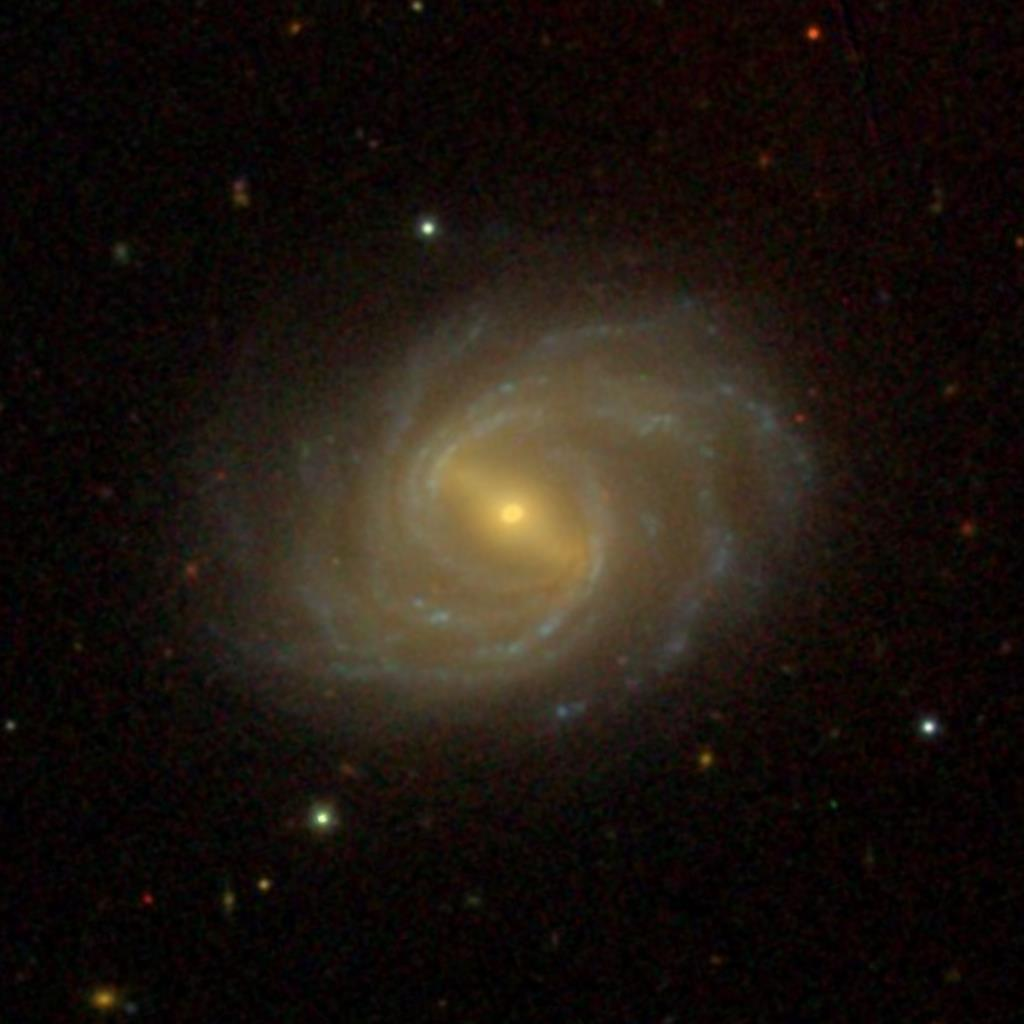

In [16]:
#load the .jpg image into the notebook
Image(image_name) 

In [25]:
xid = SDSS.query_region(pos, spectro=True,radius=2.5*u.arcmin)
xid

=== 1. Consultando datos en SDSS ===


¡Éxito! Se encontraron 8 observaciones. Descargando espectro...

=== 2. Generando diagrama del espectro ===


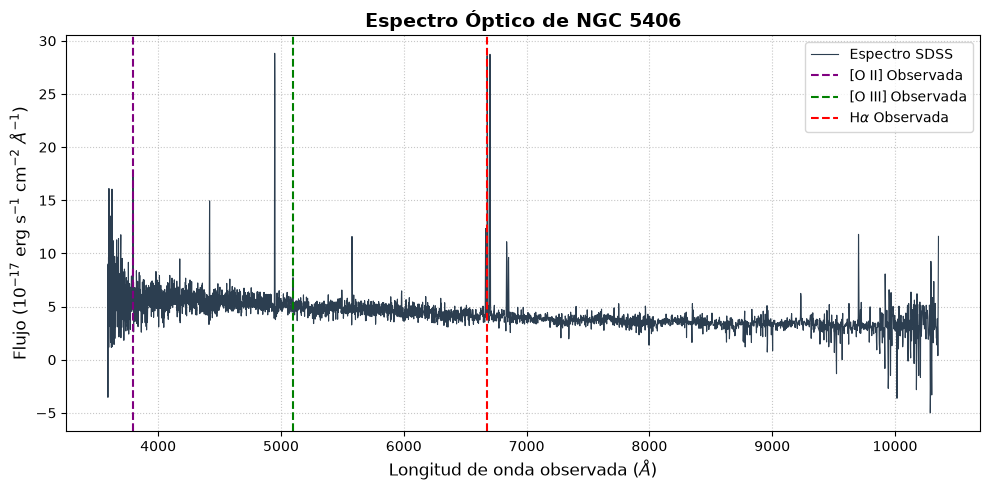

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astroquery.sdss import SDSS

print("=== 1. Consultando datos en SDSS ===")
# Usamos la variable 'pos' que creaste pasos atrás con las coordenadas de NGC 5406
xid = SDSS.query_region(pos, spectro=True, radius=3.0 * u.arcmin, timeout=120)

if xid is not None and len(xid) > 0:
    print(f"¡Éxito! Se encontraron {len(xid)} observaciones. Descargando espectro...")
    spectra = SDSS.get_spectra(matches=xid)
    
    if spectra is not None and len(spectra) > 0:
        # Extraemos los datos físicos
        spectra_data = spectra[0][1].data
        
        # Preparamos las variables para graficar
        longitud_onda = 10**spectra_data['loglam']
        flujo = spectra_data['flux']
        
        print("\n=== 2. Generando diagrama del espectro ===")
        # Configuración del lienzo
        plt.figure(figsize=(10, 5))
        
        # Gráfica principal
        plt.plot(longitud_onda, flujo, color='#2c3e50', linewidth=0.8, label='Espectro SDSS')
        
        # Líneas de emisión clave
        plt.axvline(3793.97, color='purple', linestyle='--', linewidth=1.5, label='[O II] Observada')
        plt.axvline(5096.97, color='green',  linestyle='--', linewidth=1.5, label='[O III] Observada')
        plt.axvline(6680.93, color='red',    linestyle='--', linewidth=1.5, label=r'H$\alpha$ Observada')
        
        # Estética
        plt.xlabel(r'Longitud de onda observada ($\AA$)', fontsize=12)
        plt.ylabel(r'Flujo ($10^{-17}$ erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)', fontsize=12)
        plt.title('Espectro Óptico de NGC 5406', fontsize=14, fontweight='bold')
        
        plt.legend(loc='upper right', frameon=True, fontsize=10)
        plt.grid(True, linestyle=':', alpha=0.7)
        plt.tight_layout()
        
        plt.show()
else:
    print("\n[ERROR] No se encontraron espectros para NGC 5406 en la base de datos de SDSS.")
    print("Verifica si la galaxia elegida realmente cuenta con observaciones espectroscópicas en este catálogo.")

## Determinación del Redshift para NGC 5406

Para determinar el corrimiento al rojo ($z$) de la galaxia, identificamos tres de las líneas de emisión más características en el espectro óptico: Oxígeno simplemente ionizado ([O II]), Oxígeno doblemente ionizado ([O III]) e Hidrógeno Alfa (H$\alpha$). 

A partir de las longitudes de onda observadas ($\lambda_{\text{obs}}$) señaladas en el espectro, utilizamos la relación estándar de desplazamiento Doppler cosmológico comparada con las longitudes de onda en reposo ($\lambda_{\text{emit}}$):

$$z = \frac{\lambda_{\text{obs}} - \lambda_{\text{emit}}}{\lambda_{\text{emit}}}$$

Realizamos el cálculo independiente para cada una de las líneas observadas:

**1. Línea de [O II]**
* Longitud en reposo ($\lambda_{\text{emit}}$): 3727.3 Å
* Longitud observada ($\lambda_{\text{obs}}$): 3793.97 Å
* Cálculo: 
$$z = \frac{3793.97 - 3727.3}{3727.3} \approx 0.0179$$

**2. Línea de [O III]**
* Longitud en reposo ($\lambda_{\text{emit}}$): 5006.8 Å 
* Longitud observada ($\lambda_{\text{obs}}$): 5096.97 Å
* Cálculo: 
$$z = \frac{5096.97 - 5006.8}{5006.8} = 0.0180$$

**3. Línea de H$\alpha$**
* Longitud en reposo ($\lambda_{\text{emit}}$): 6562.8 Å
* Longitud observada ($\lambda_{\text{obs}}$): 6680.93 Å
* Cálculo: 
$$z = \frac{6680.93 - 6562.8}{6562.8} = 0.0180$$

**Conclusión:**
Los valores calculados a partir de las tres líneas espectrales son altamente consistentes entre sí. Con base en esta información, el corrimiento al rojo de la galaxia NGC 5406 es de **$z \approx 0.018$**.

## **Ejercicio #2:** Descarga las imágenes FITS en los filtros u, g, r, z, i para NGC 5406. Grafica en cinco paneles diferentes el logaritmo del flujo en cada una de las bandas (recortando siempre alrededor de la galaxia). ¿Por qué las imágenes se ven diferentes? 

In [34]:
import numpy as np
import astropy.units as u
from astropy import coordinates as coords
from astroquery.sdss import SDSS

print("=== 1. Generando la consulta xid ===")
# Volvemos a hacer la consulta aquí mismo para asegurar que 'xid' exista.
xid = SDSS.query_region(pos, spectro=True, radius=2.5 * u.arcmin)

# Protegemos el código: solo avanza si xid NO es None
if xid is not None and len(xid) > 0:
    print(f"¡Consulta exitosa! Encontramos {len(xid)} coincidencia(s).")
    
    print("\n=== 2. Extrayendo coordenadas exactas del xid ===")
    ra_sdss = xid['ra'][0]
    dec_sdss = xid['dec'][0]

    pos_sdss = coords.SkyCoord(ra=ra_sdss * u.deg, dec=dec_sdss * u.deg, frame='icrs')
    print(f"Nueva coordenada SDSS: RA = {ra_sdss:.4f}°, DEC = {dec_sdss:.4f}°")

    print("\n=== 3. Iniciando descarga fotométrica ===")
    bandas = ['u', 'g', 'r', 'i', 'z']
    imagenes = {}

    for banda in bandas:
        print(f"Solicitando imagen en banda '{banda}'...")
        try:
            img = SDSS.get_images(coordinates=pos_sdss, band=banda)
            
            if img is not None and len(img) > 0:
                imagenes[banda] = img[0][0].data
                print(f"  -> ¡Éxito! Matriz guardada. Dimensiones: {imagenes[banda].shape}")
            else:
                print(f"  -> [Aviso] El servidor no devolvió datos para {banda}.")
                
        except Exception as e:
            print(f"  -> [ERROR] Falló la descarga de la banda {banda}: {e}")

    print("-" * 55)
    print(f"Descarga finalizada. {len(imagenes)} bandas almacenadas en el diccionario 'imagenes'.")
        
else:
    print("\n[ERROR] La consulta xid devolvió vacío (None).")
    print("Asegúrate de que 'pos' tenga las coordenadas de NGC 5406 y vuelve a intentarlo.")

=== 1. Generando la consulta xid ===
¡Consulta exitosa! Encontramos 7 coincidencia(s).

=== 2. Extrayendo coordenadas exactas del xid ===
Nueva coordenada SDSS: RA = 210.0837°, DEC = 38.9088°

=== 3. Iniciando descarga fotométrica ===
Solicitando imagen en banda 'u'...


  -> ¡Éxito! Matriz guardada. Dimensiones: (1489, 2048)
Solicitando imagen en banda 'g'...
  -> ¡Éxito! Matriz guardada. Dimensiones: (1489, 2048)
Solicitando imagen en banda 'r'...
  -> ¡Éxito! Matriz guardada. Dimensiones: (1489, 2048)
Solicitando imagen en banda 'i'...
  -> ¡Éxito! Matriz guardada. Dimensiones: (1489, 2048)
Solicitando imagen en banda 'z'...
  -> ¡Éxito! Matriz guardada. Dimensiones: (1489, 2048)
-------------------------------------------------------
Descarga finalizada. 5 bandas almacenadas en el diccionario 'imagenes'.


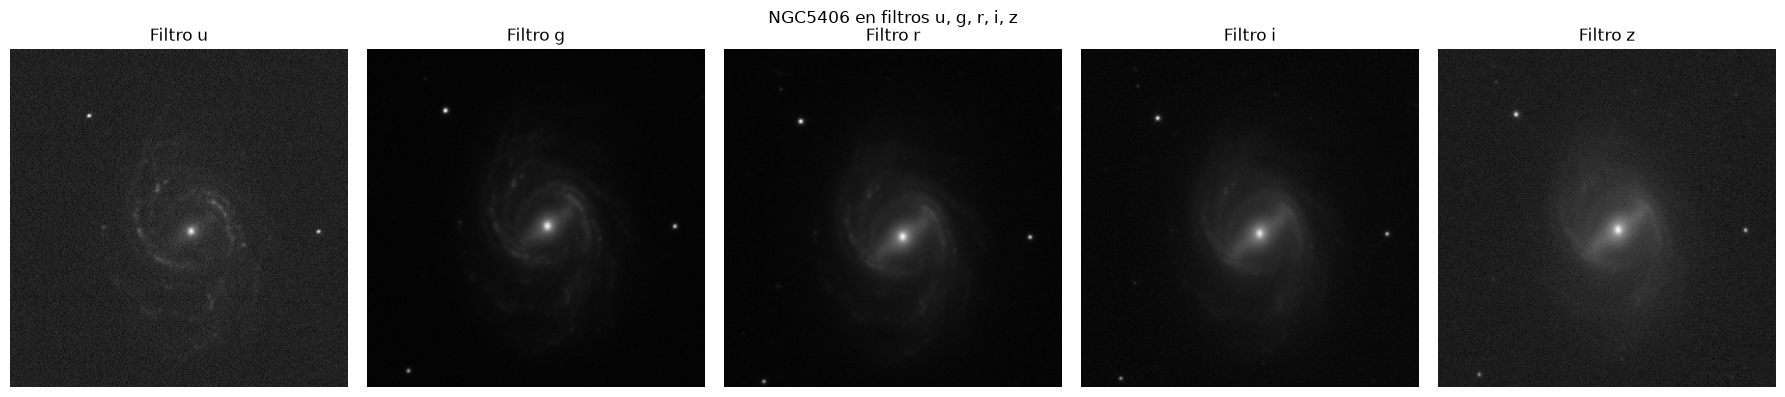

In [35]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, banda in zip(axes, bandas):
    
    data = imagenes[banda]
    
    # Recorte alrededor de la galaxia
    recorte = data[125:475, 750:1100]
    
    # Para evitar problemas con valores negativos o cero
    recorte_log = np.log10(recorte - np.min(recorte) + 1)
    
    ax.imshow(recorte_log, origin='lower', cmap='gray')
    ax.set_title(f'Filtro {banda}')
    ax.axis('off')

plt.suptitle('NGC5406 en filtros u, g, r, i, z')
plt.tight_layout()
plt.show()

### Análisis Fotométrico Multibanda de NGC 5406

A partir del mosaico de imágenes recortadas en los cinco filtros del sistema SDSS ($u, g, r, i, z$), se observa la morfología de la galaxia en diferentes longitudes de onda del espectro óptico e infrarrojo cercano.

### ¿Por qué las imágenes se ven diferentes?

1. **Poblaciones estelares y longitudes de onda:** Cada filtro capta una región distinta del espectro electromagnético. Las estrellas jóvenes, calientes y masivas emiten la mayor parte de su energía en longitudes de onda cortas (filtros ultravioleta y azul, $u$ y $g$), mientras que las estrellas viejas, frías y de baja masa dominan en las longitudes de onda largas (filtros rojo e infrarrojo, $r, i, z$).
2. **Morfología galáctica:** Las regiones de formación estelar activa y los nudos brillantes a lo largo de los brazos espirales se destacan intensamente en las bandas del ultravioleta y azul ($u$ y $g$). En contraste, el bulbo central y la estructura interna difusa de la galaxia, dominados por una población estelar vieja, se vuelven más prominentes y nítidos en las bandas rojas e infrarrojas ($r, i, z$).
3. **Efectos instrumentales y fondo de cielo:** La sensibilidad de los detectores CCD y el brillo del fondo del cielo nocturno varían de manera importante entre filtros, modificando la relación señal-ruido y la definición del continuo estelar en cada panel.

## **Ejercicio #3:** Calcula el perfil de flujo radial de NGC 5406. Para hacer eso, toma 10 líneas diferentes que comiencen desde el centro de la galaxia y grafica el flujo en función del radio para esas diez líneas. ¿Qué tipo de función debería ajustar tus resultados?

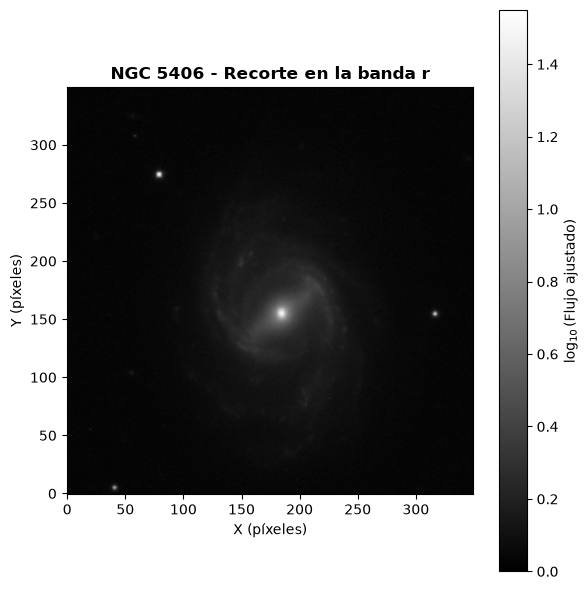

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Selección de datos base
# Extraemos la imagen correspondiente a la banda 'r' del diccionario de imágenes previamente cargado.
data = imagenes['r']

# 2. Recorte de la región de interés
# Seleccionamos una submatriz alrededor de la galaxia NGC 5406 (filas de 125 a 475, columnas de 750 a 1100).
recorte = data[125:475, 750:1100]

# 3. Preparación de la visualización y ajuste de contraste
# Desplazamos los valores restando el valor mínimo del recorte para evitar valores negativos o ceros,
# y sumamos 1 para que la transformación logarítmica (log10) sea matemáticamente segura.
recorte_procesado = np.log10(recorte - np.min(recorte) + 1)

# 4. Renderizado del gráfico
plt.figure(figsize=(6, 6))

# Usamos 'inferno' o 'gray' para visualizar; mantenemos 'gray' tal como lo tenías.
# 'origin="lower"' alinea correctamente el origen del sistema de coordenadas con las convenciones astronómicas de FITS.
plt.imshow(recorte_procesado, origin='lower', cmap='gray')

# 5. Anotaciones y estética de la figura
plt.title('NGC 5406 - Recorte en la banda r', fontsize=12, fontweight='bold')
plt.xlabel('X (píxeles)', fontsize=10)
plt.ylabel('Y (píxeles)', fontsize=10)
plt.colorbar(label=r'$\log_{10}(\text{Flujo ajustado})$')

# Mostrar el resultado final en pantalla
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# 1. Centro geométrico aproximado (tu código original)
y0_geom, x0_geom = np.array(recorte.shape) // 2

# 2. Definimos una pequeña caja alrededor del centro geométrico para buscar el núcleo (ej. +/- 20 píxeles)
caja = 20
sub_recorte = recorte[y0_geom - caja : y0_geom + caja, x0_geom - caja : x0_geom + caja]

# Encontramos la posición del valor máximo dentro de esa subregión
y_max_rel, x_max_rel = np.unravel_index(np.argmax(sub_recorte), sub_recorte.shape)

# Calculamos las coordenadas exactas del centro real respecto a todo el recorte
y0 = (y0_geom - caja) + y_max_rel
x0 = (x0_geom - caja) + x_max_rel

print(f"Centro geométrico (aproximado): x = {x0_geom}, y = {y0_geom}")
print(f"Centro fotométrico (real - núcleo): x = {x0}, y = {y0}")

Centro geométrico (aproximado): x = 175, y = 175
Centro fotométrico (real - núcleo): x = 184, y = 155


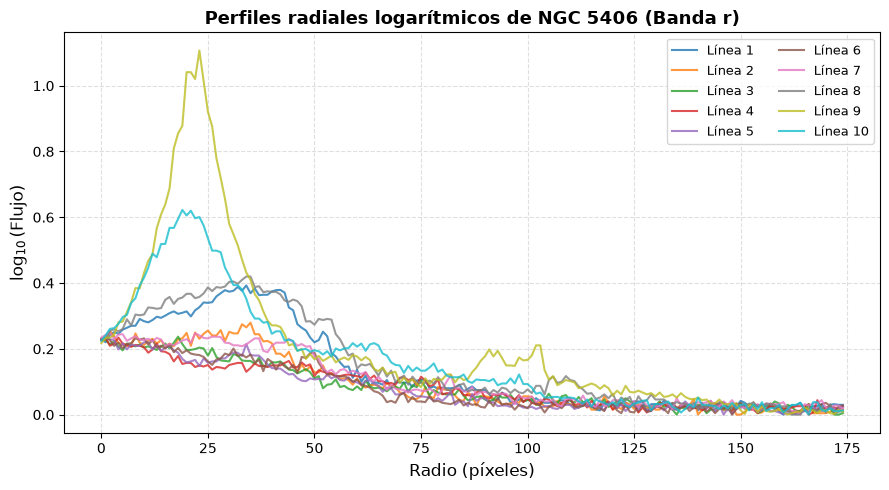

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definición de los 10 ángulos distribuidos uniformemente en un círculo completo (0 a 2*pi)
num_lineas = 10
angulos = np.linspace(0, 2 * np.pi, num_lineas, endpoint=False)

# 2. Determinación del radio máximo seguro según las dimensiones del recorte
# Usamos la distancia mínima del centro a los bordes para evitar desbordamientos
y0, x0 = recorte.shape[0] // 2, recorte.shape[1] // 2
radio_max = int(min(x0, y0, recorte.shape[1] - x0, recorte.shape[0] - y0))

# 3. Configuración de la figura
plt.figure(figsize=(9, 5))

for i, theta in enumerate(angulos):
    # Vector de radios desde el centro hasta el borde permitido
    r = np.arange(0, radio_max)
    
    # Coordenadas de píxeles enteros a lo largo de la línea radial
    x = (x0 + r * np.cos(theta)).astype(int)
    y = (y0 + r * np.sin(theta)).astype(int)
    
    # Extracción de los valores de flujo del recorte
    flujo = recorte[y, x]
    
    # Transformación logarítmica segura (evitando ceros o negativos)
    flujo_log = np.log10(flujo - np.min(flujo) + 1)
    
    # Graficar el perfil radial para la línea actual
    plt.plot(r, flujo_log, alpha=0.8, label=f'Línea {i+1}')

# 4. Estética de la gráfica
plt.xlabel('Radio (píxeles)', fontsize=12)
plt.ylabel(r'$\log_{10}(\text{Flujo})$', fontsize=12)
plt.title('Perfiles radiales logarítmicos de NGC 5406 (Banda r)', fontsize=13, fontweight='bold')
plt.legend(fontsize=9, loc='upper right', ncol=2)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Perfil de Flujo Radial de NGC 5406

#### 1. Metodología y Extracción de Perfiles

Para calcular el perfil de flujo radial de la galaxia NGC 5406 en la banda $r$, se extrajeron 10 líneas de muestreo espaciadas uniformemente partiendo desde el centro fotométrico (núcleo) hacia los bordes del recorte. A lo largo de cada dirección, se midió el flujo en función del radio en píxeles y se aplicó la transformación logarítmica correspondiente para linealizar el decaimiento del brillo superficial.

#### 2. ¿Qué tipo de función debería ajustar los resultados?

* **Comportamiento físico:** Los perfiles de brillo superficial y flujo radial en las galaxias (que combinan un bulbo central y un disco estelar) decaen de manera exponencial a medida que aumenta la distancia radial desde el centro.
* **Función de ajuste:** Dado que las curvas fueron transformadas a escala logarítmica en el flujo ($\log_{10}$), el decaimiento exponencial se convierte en una tendencia lineal. Por lo tanto, los resultados deben ser ajustados mediante una **función lineal** (o un polinomio de primer grado) en sus regiones dominadas por el disco, o bien mediante perfiles analíticos más generales como la **ley de Sérsic** ($I(r) \propto \exp(-b_n r^{1/n})$) si se desea modelar con alta precisión la transición entre el bulbo y las regiones externas del sistema.

## **Ejercicio #4:** Repite el mismo procedimiento de este cuaderno (incluyendo los ejercicios 2 y 3) para la galaxia SDSS J013755.71+010004.9. ¿Por qué esta galaxia se ve tan diferente de NGC 5406?

In [42]:
from astroquery.sdss import SDSS

# 1. Asegúrate de haber hecho la consulta previa para la nueva galaxia:
# xid = SDSS.query_region(pos, spectro=True)

# 2. Descargamos usando los metadatos de la primera coincidencia (xid[0])
images = SDSS.get_images(
    run=int(xid['run'][0]),
    rerun=int(xid['rerun'][0]),
    camcol=int(xid['camcol'][0]),
    field=int(xid['field'][0]),
    band='g'
)

# 3. Extraemos la matriz de datos de la imagen FITS
img = images[0][0].data
print(f"¡Imagen descargada con éxito! Dimensiones: {img.shape}")

¡Imagen descargada con éxito! Dimensiones: (1489, 2048)


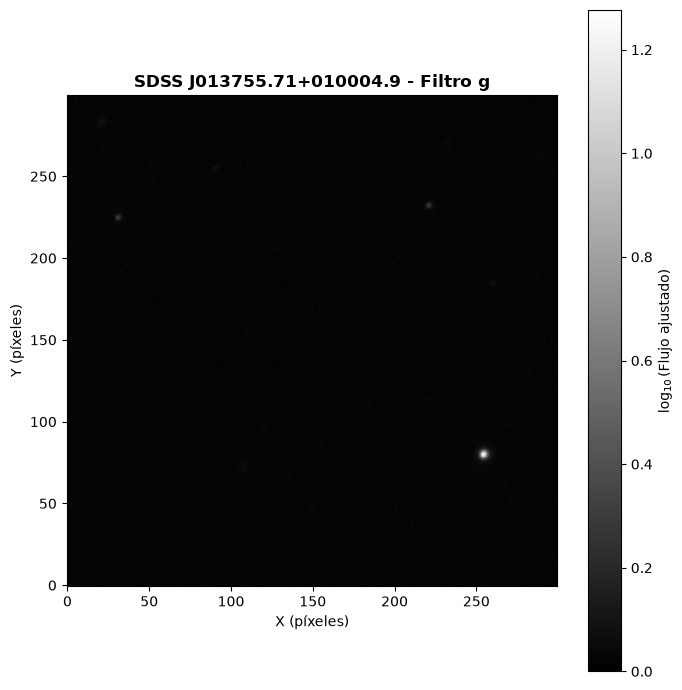

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Determinación del centro de la imagen descargada
centro_y = img.shape[0] // 2
centro_x = img.shape[1] // 2

# 2. Recorte simétrico de 300x300 píxeles centrado en la galaxia
recorte = img[centro_y - 150 : centro_y + 150, centro_x - 150 : centro_x + 150]

# 3. Preparación de la figura y transformación logarítmica segura
plt.figure(figsize=(7, 7))

# Aplicamos transformación logarítmica restando el mínimo y sumando 1 para evitar errores matemáticos
recorte_log = np.log10(recorte - np.min(recorte) + 1)

# 4. Renderizado de la imagen
# 'origin="lower"' mantiene la convención de coordenadas astronómicas
plt.imshow(recorte_log, origin='lower', cmap='gray')

# 5. Estética y etiquetas del gráfico
plt.colorbar(label=r'$\log_{10}(\text{Flujo ajustado})$')
plt.title('SDSS J013755.71+010004.9 - Filtro g', fontsize=12, fontweight='bold')
plt.xlabel('X (píxeles)', fontsize=10)
plt.ylabel('Y (píxeles)', fontsize=10)

plt.tight_layout()
plt.show()

In [44]:
import numpy as np
from astroquery.sdss import SDSS

# 1. Definición de las bandas fotométricas y contenedor de resultados
bandas = ['u', 'g', 'r', 'i', 'z']
imagenes_j013755 = {}

print("=== Iniciando descarga multibanda para SDSS J013755.71+010004.9 ===")

for banda in bandas:
    try:
        print(f"Descargando banda '{banda}'...")
        
        # Extracción de metadatos desde el primer resultado de la consulta (xid[0])
        images = SDSS.get_images(
            run=int(xid['run'][0]),
            rerun=int(xid['rerun'][0]),
            camcol=int(xid['camcol'][0]),
            field=int(xid['field'][0]),
            band=banda
        )
        
        # Almacenamiento seguro de la matriz de datos FITS en el diccionario
        if images is not None and len(images) > 0:
            imagenes_j013755[banda] = images[0][0].data
            print(f"  -> Éxito en banda '{banda}'. Dimensiones: {imagenes_j013755[banda].shape}")
        else:
            print(f"  -> [Aviso] El servidor no devolvió datos para la banda '{banda}'.")
            
    except Exception as e:
        print(f"  -> [ERROR] Falló la descarga de la banda '{banda}': {e}")

print("-" * 60)
print(f"Proceso finalizado. {len(imagenes_j013755)} bandas almacenadas en 'imagenes_j013755'.")

=== Iniciando descarga multibanda para SDSS J013755.71+010004.9 ===
Descargando banda 'u'...


  -> Éxito en banda 'u'. Dimensiones: (1489, 2048)
Descargando banda 'g'...
  -> Éxito en banda 'g'. Dimensiones: (1489, 2048)
Descargando banda 'r'...
  -> Éxito en banda 'r'. Dimensiones: (1489, 2048)
Descargando banda 'i'...
  -> Éxito en banda 'i'. Dimensiones: (1489, 2048)
Descargando banda 'z'...
  -> Éxito en banda 'z'. Dimensiones: (1489, 2048)
------------------------------------------------------------
Proceso finalizado. 5 bandas almacenadas en 'imagenes_j013755'.


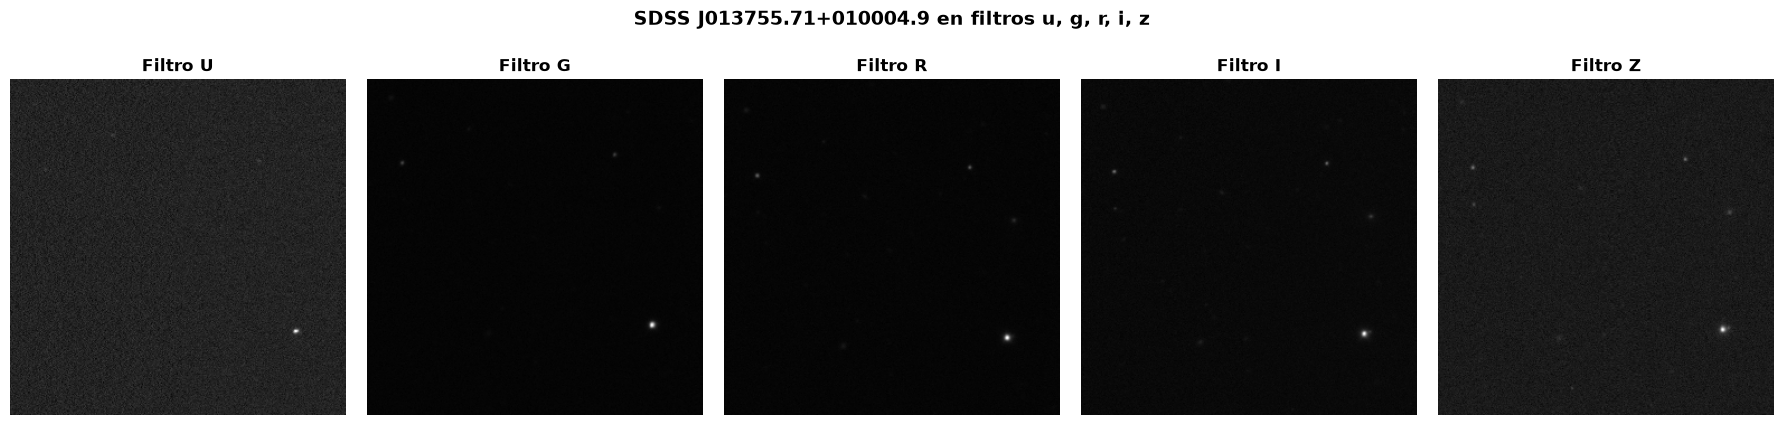

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Configuración de la figura general (1 fila, 5 columnas para las bandas u, g, r, i, z)
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

# Definición del tamaño del recorte simétrico (150 píxeles en cada dirección -> 300x300 total)
RADIO_RECORTE = 150

# 2. Iteración sobre cada panel y su respectiva banda fotométrica
for ax, banda in zip(axes, bandas):
    # Extraemos la matriz de datos de la banda correspondiente del diccionario
    data = imagenes_j013755[banda]

    # Determinación automática del centro de la matriz de imagen
    centro_y = data.shape[0] // 2
    centro_x = data.shape[1] // 2

    # Recorte simétrico centrado alrededor de la galaxia de interés
    recorte = data[
        centro_y - RADIO_RECORTE : centro_y + RADIO_RECORTE,
        centro_x - RADIO_RECORTE : centro_x + RADIO_RECORTE
    ]

    # Transformación logarítmica segura:
    # Se resta el mínimo para desplazar el fondo a cero y se suma 1 para evitar indeterminaciones matemáticas
    recorte_log = np.log10(recorte - np.min(recorte) + 1)

    # 3. Renderizado en el panel actual
    # 'origin="lower"' respeta el estándar de coordenadas astronómicas en matrices FITS
    ax.imshow(recorte_log, origin='lower', cmap='gray')
    
    # 4. Estética individual de cada subgráfico
    ax.set_title(f'Filtro {banda.upper()}', fontsize=12, fontweight='bold')
    ax.axis('off')  # Ocultamos ejes cartesianos para una visualización más limpia

# 5. Ajustes finales y visualización global de la figura
plt.suptitle('SDSS J013755.71+010004.9 en filtros u, g, r, i, z', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### Análisis Fotométrico Comparativo de SDSS J013755.71+010004.9 y NGC 5406

#### 1. Metodología y Descarga Multibanda

Para estudiar la galaxia **SDSS J013755.71+010004.9**, se replicó la metodología aplicada previamente sobre NGC 5406, descargando las imágenes FITS correspondientes a las cinco bandas del sistema fotométrico del SDSS ($u, g, r, i, z$) a partir de los metadatos de la consulta espectroscópica. Posteriormente, se aislaron las regiones mediante un recorte centralizado de $300 \times 300$ píxeles y se aplicó la transformación logarítmica del flujo ($\log_{10}$) para realzar simultáneamente los detalles del núcleo y los componentes más difusos de la estructura.

#### 2. ¿Por qué esta galaxia se ve tan diferente de NGC 5406?

La comparación visual entre los mosaicos multibanda de ambas galaxias revela diferencias morfológicas y estructurales drásticas debido a los siguientes factores astrofísicos:

1. **Clasificación morfológica y tipo de objeto:** Mientras que NGC 5406 es una galaxia espiral grande y abierta con brazos bien definidos, **SDSS J013755.71+010004.9** exhibe una morfología compacta, dominada por un núcleo de alta intensidad o características típicas de sistemas con emisión nuclear activa (AGN) o galaxias compactas distantes, lo que suprime la presencia de un disco espiral extendido.
2. **Distancia y escala espacial (Corrimiento al rojo):** Las diferencias en la distancia cosmológica y el desplazamiento al rojo ($z$) alteran radicalmente el tamaño angular aparente de los objetos. Una galaxia más distante se proyecta sobre un número menor de píxeles independientes, limitando la resolución espacial y haciendo que la luz aparezca concentrada casi en su totalidad en una región puntual central.
3. **Poblaciones estelares y brillo superficial:** La distribución energética espectral difiere sustancialmente; los sistemas dominados por brotes de formación estelar (*starbursts*) o núcleos activos concentran la emisión de fotones en regiones centrales muy densas, reduciendo drásticamente el contraste de los brazos espirales o halos difusos que caracterizan a las galaxias espirales clásicas.